# Exploring quantum designs with `qdesigns`

An interactive playground for **mutually unbiased bases (MUBs)** and **quantum Latin squares (QLS)**. Run the cells top to bottom, then change `d` / `n` and re-run to explore any dimension you like.

The setup cell below makes `qdesigns` importable whether or not you have `pip install -e .`'d the package. You need `numpy` and `matplotlib` installed (`pip install matplotlib`).

In [10]:
%matplotlib inline
import pathlib
import sys

import numpy as np

# Make the package (../src) and this examples/ folder importable.
_HERE = pathlib.Path.cwd()
for cand in (_HERE, _HERE / 'src', _HERE.parent / 'src', _HERE / 'examples'):
    if cand.exists() and str(cand) not in sys.path:
        sys.path.insert(0, str(cand))

import qdesigns_viz as viz

import qdesigns as qd

np.set_printoptions(precision=3, suppress=True, linewidth=140)
print('qdesigns version:', qd.__version__)

qdesigns version: 0.1.0


## 1. Mutually unbiased bases

Set `d` to any **supported** dimension and re-run: `2`, any **odd prime** (3, 5, 7, 11, ...), the **odd prime powers** (9, 25, 27, 49, ...), and the even prime powers **4** and **8**.

In [11]:
d = 4                      # <-- change me (try 3, 5, 7, 8, 9, 25, 27)
mubs = qd.mub.construct(d)
print(mubs)
print(qd.verify(mubs).summary())

MUBSet(dimension=4, count=5, construction='galois-ring GR(4,r) (Klappenecker-Roetteler 2004)')
[PASS] mub_set (atol=1e-09)
  [ok] each basis orthonormal
  [ok] pairwise mutually unbiased
    - dimension: 4
    - num_bases: 5
    - construction: galois-ring GR(4,r) (Klappenecker-Roetteler 2004)


Inspect the raw vectors of one basis (columns are the basis vectors):

In [12]:
basis_index = 0
mubs.bases[basis_index]

array([[ 0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j],
       [ 0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j],
       [ 0.5+0.j, -0.5+0.j, -0.5+0.j,  0.5+0.j],
       [ 0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j]])

Visualize the whole set. Top row = phase of each basis; bottom = `|<e_i|f_j>|` for all stacked vectors (identity diagonal blocks = orthonormal, uniform off-blocks = `1/sqrt(d)` = unbiased).

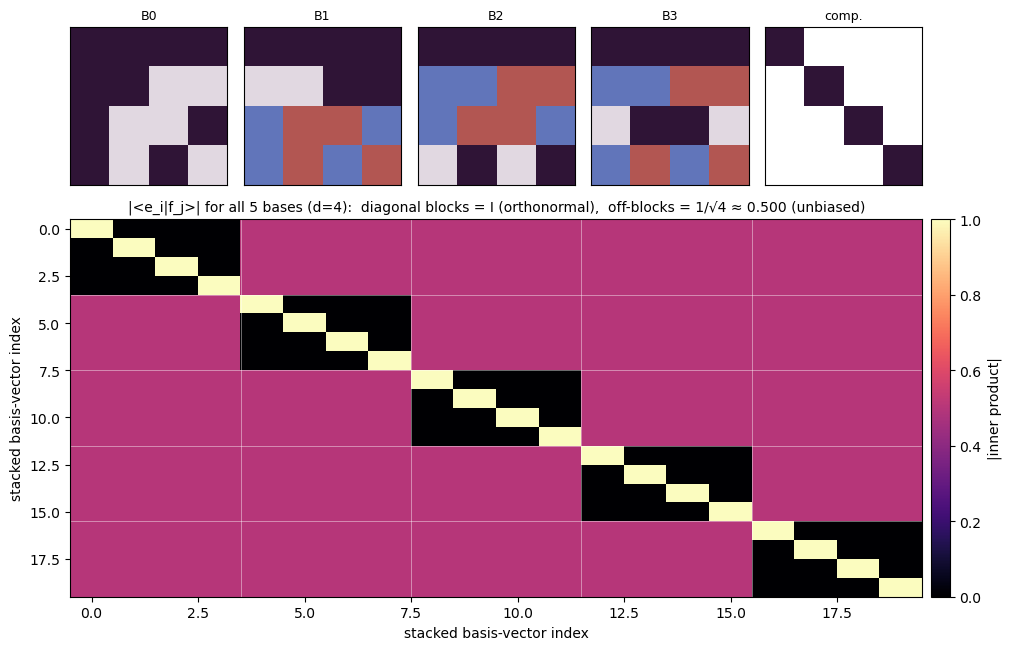

In [13]:
viz.plot_mub(mubs);

Quick sweep: verify a complete set exists and checks out for several dimensions.

In [14]:
for dim in [2, 3, 4, 5, 7, 8, 9, 25, 27]:
    m = qd.mub.construct(dim)
    cert = qd.verify(m)
    print(f'd={dim:>2}: {m.count} bases  ok={cert.ok}  [{m.construction}]')

d= 2: 3 bases  ok=True  [pauli-eigenbases]
d= 3: 4 bases  ok=True  [wootters-fields (odd prime)]
d= 4: 5 bases  ok=True  [galois-ring GR(4,r) (Klappenecker-Roetteler 2004)]
d= 5: 6 bases  ok=True  [wootters-fields (odd prime)]
d= 7: 8 bases  ok=True  [wootters-fields (odd prime)]
d= 8: 9 bases  ok=True  [galois-ring GR(4,r) (Klappenecker-Roetteler 2004)]
d= 9: 10 bases  ok=True  [galois-field GF(3^2) trace (Wootters-Fields)]
d=25: 26 bases  ok=True  [galois-field GF(5^2) trace (Wootters-Fields)]
d=27: 28 bases  ok=True  [galois-field GF(3^3) trace (Wootters-Fields)]


## 2. Quantum Latin squares

A QLS of order `n` is an `n x n` grid of unit vectors in `C^n` where every row and every column is an orthonormal basis. Start with the order-4 Bell-state square:

QuantumLatinSquare(order=4, name='bell-order4')
[PASS] quantum_latin_square (atol=1e-09)
  [ok] every row is an orthonormal basis
  [ok] every column is an orthonormal basis
    - order: 4
    - name: bell-order4


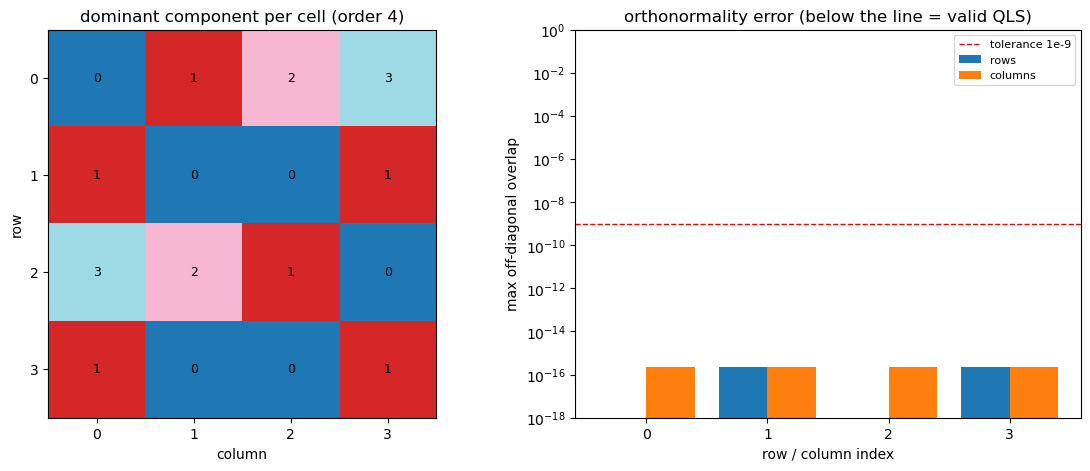

In [15]:
q = qd.qls.bell_order4()
print(q)
print(qd.verify(q).summary())
viz.plot_qls(q);

Build a **classical** QLS of any order from a Latin square (here a cyclic one). Change `n` and re-run.

[PASS] quantum_latin_square (atol=1e-09)
  [ok] every row is an orthonormal basis
  [ok] every column is an orthonormal basis
    - order: 5
    - name: cyclic-5


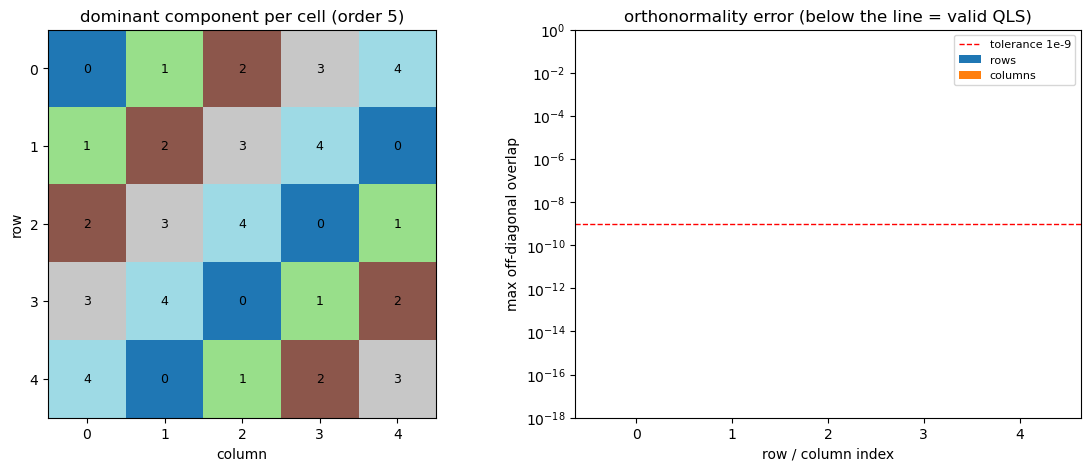

In [16]:
n = 5                      # <-- change me
square = np.array([[(i + j) % n for j in range(n)] for i in range(n)])
q = qd.qls.from_latin_square(square, name=f'cyclic-{n}')
print(qd.verify(q).summary())
viz.plot_qls(q);

Or build your own from an `(n, n, n)` array of cell vectors (`cells[i, j]` is the state at row `i`, column `j`) and verify it:

In [17]:
cells = qd.qls.bell_order4().cells.copy()   # edit these vectors as you like
myq = qd.qls.from_array(cells, name='custom')
print(qd.verify(myq).summary())

[PASS] quantum_latin_square (atol=1e-09)
  [ok] every row is an orthonormal basis
  [ok] every column is an orthonormal basis
    - order: 4
    - name: custom


## 3. Export to the machine-readable schema

Any design object serializes to the `qdesign` JSON schema (dimensions, data, and the verification result).

In [18]:
path = qd.export(mubs, f'mub_d{d}.qdesign.json')
print('wrote', path)

wrote mub_d4.qdesign.json
